# Home Credit Default Risk
Predict how capable each applicant is of repaying a loan?

Kaggle: https://www.kaggle.com/competitions/home-credit-default-risk/data

Submissions are evaluated on ROC-AUC score

Data:
- application_{train|test}.csv - main table, one row represents one loan;
- bureau.csv - all client's previous credits provided by other financial institutions;
- bureau_balance.csv - monthly balances of previous credits;
- POS_CASH_balance.csv - monthly balance snapshots of previous *point of sales* and cash loans that the applicant had with Home Credit;
- credit_card_balance.csv - monthly balance snapshots of previous credit cards that the applicant has with Home Credit;
- previous_application.css - all previous applicants for Home Credit loans of clients who have loans in our sample;
- installments_payments.csv - repayment history for the previously distributed credits in Home Credit;
- HomeCredit_columns_description.csv - description for columns.

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import random
warnings.filterwarnings('ignore')
random.seed(200)

In [143]:
DATA_PATH = Path('./data')
df_train = pd.read_csv(DATA_PATH / 'application_train.csv')
df_test = pd.read_csv(DATA_PATH / 'application_test.csv')

print(f'Train shape: {df_train.shape}')
print(f'Test shape: {df_test.shape}')
print(f'\n Train columns: {df_train.columns.tolist()[:10]}...')

Train shape: (307511, 122)
Test shape: (48744, 121)

 Train columns: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']...


In [144]:
df_train.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


![image.png](./img/home_credit.png)

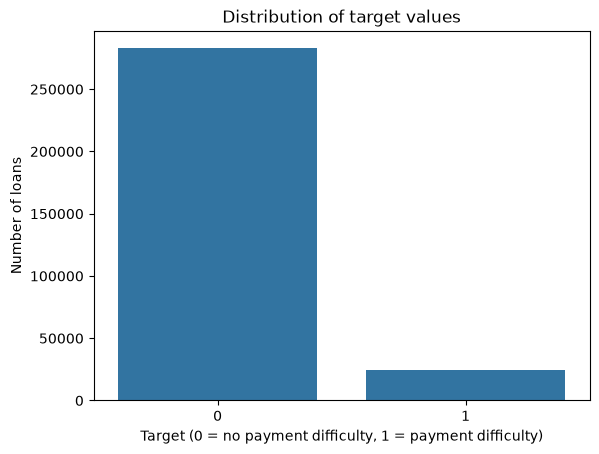

In [145]:
sns.countplot(data=df_train, x='TARGET')
plt.title('Distribution of target values')
plt.xlabel('Target (0 = no payment difficulty, 1 = payment difficulty)')
plt.ylabel('Number of loans')
plt.show()

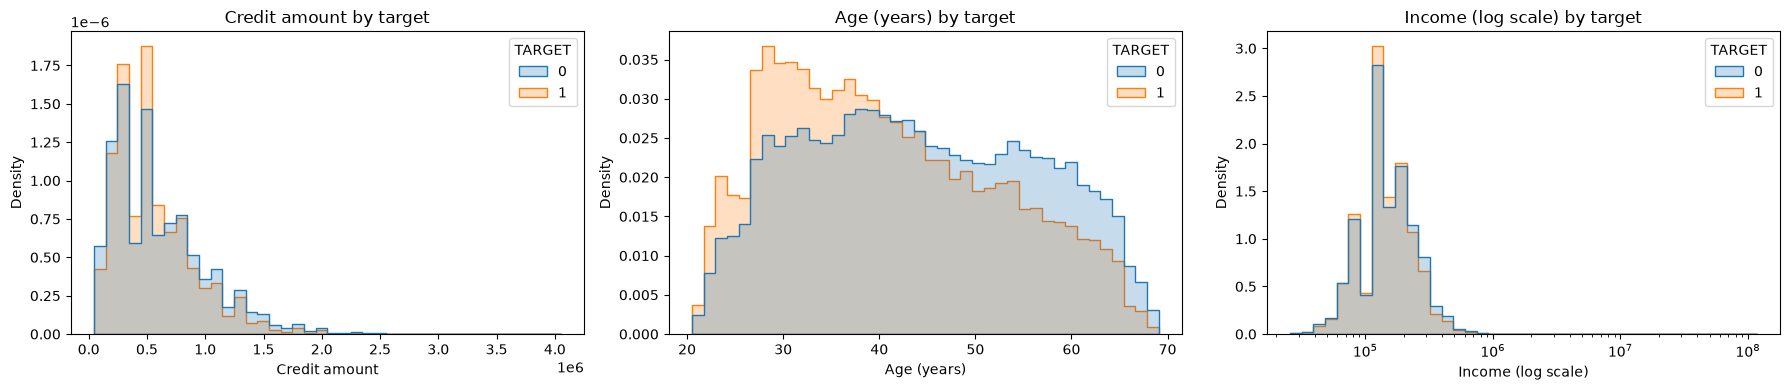

In [146]:
plot_df = df_train.assign(AGE_YEARS=-df_train['DAYS_BIRTH'] / 365.25)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, column, label in zip(
    axes,
    ['AMT_CREDIT', 'AGE_YEARS', 'AMT_INCOME_TOTAL'],
    ['Credit amount', 'Age (years)', 'Income (log scale)'],
):
    sns.histplot(
        data=plot_df, x=column, hue='TARGET', bins=40,
        stat='density', common_norm=False, element='step',
        log_scale=(column == 'AMT_INCOME_TOTAL'), ax=ax,
    )
    ax.set_title(f'{label} by target')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

## XGBoost with organization embedding
Split the data into train, validation, and test sets. Train one XGBoost model with application features, flag scores, a region rating, social-circle delinquency rates, and an organization embedding. For the social-circle rates, 30 and 60 mean days past due.


In [147]:
from sklearn.model_selection import train_test_split

contact_flags = [
    'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
    'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
]

document_flags = [f'FLAG_DOCUMENT_{number}' for number in range(2, 22)]
rating_columns = ['REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT']
social_observed = [f'OBS_{days}_CNT_SOCIAL_CIRCLE' for days in (30, 60)]
social_defaulted = [f'DEF_{days}_CNT_SOCIAL_CIRCLE' for days in (30, 60)]
social_columns = social_observed + social_defaulted

numeric_raw = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_POPULATION_RELATIVE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'DAYS_LAST_PHONE_CHANGE', 'OWN_CAR_AGE',
]
categorical = [
    'NAME_CONTRACT_TYPE', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
]
feature_columns = numeric_raw + contact_flags + document_flags + rating_columns + social_columns + categorical + ['ORGANIZATION_TYPE']
X = df_train[feature_columns]
X_kaggle_test = df_test[feature_columns]
y = df_train['TARGET']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=200
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25,
    stratify=y_train_val, random_state=200
)
X_train, X_test = X_train.align(X_test, join='inner', axis=1)
X_val = X_val[X_train.columns]
X_kaggle_test = X_kaggle_test[X_train.columns]
assert all(data.columns.equals(X_train.columns) for data in (X_val, X_test, X_kaggle_test))
print(f'All datasets have the same {len(feature_columns)} input columns.')
for name, labels in [('train', y_train), ('validation', y_val), ('test', y_test)]:
    print(f'{name}: {len(labels):,} rows, target rate {labels.mean():.2%}')


All datasets have the same 54 input columns.
train: 184,506 rows, target rate 8.07%
validation: 61,502 rows, target rate 8.07%
test: 61,503 rows, target rate 8.07%


In [148]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.pipeline import Pipeline

def make_features(frame):
    frame = frame.copy()
    frame['CONTACT_FLAG_SCORE'] = frame[contact_flags].sum(axis=1) / len(contact_flags)
    frame['DOCUMENT_FLAG_SCORE'] = frame[document_flags].sum(axis=1) / len(document_flags)
    city = frame['REGION_RATING_CLIENT_W_CITY'].replace(-1, np.nan)
    region = frame['REGION_RATING_CLIENT'].replace(-1, np.nan)
    frame['REGION_RATING_SCORE'] = (0.7 * city + 0.3 * region).fillna(city).fillna(region)
    for days in (30, 60):
        observed = frame[f'OBS_{days}_CNT_SOCIAL_CIRCLE']
        defaulted = frame[f'DEF_{days}_CNT_SOCIAL_CIRCLE']
        frame[f'SOCIAL_DEFAULT_RATE_{days}'] = defaulted.div(observed).where(observed.ne(0), 0)
    frame['AGE_YEARS'] = -frame['DAYS_BIRTH'] / 365.25
    frame['AGE_BIN'] = pd.cut(frame['AGE_YEARS'], bins=np.linspace(20, 70, num=11), labels=False, include_lowest=True)
    frame['DAYS_EMPLOYED_ANOM'] = frame['DAYS_EMPLOYED'].eq(365243).astype(int)
    frame['EMPLOYED_YEARS'] = -frame['DAYS_EMPLOYED'].replace(365243, np.nan) / 365.25
    frame['YEARS_SINCE_REGISTRATION'] = -frame['DAYS_REGISTRATION'] / 365.25
    frame['YEARS_SINCE_ID_PUBLISH'] = -frame['DAYS_ID_PUBLISH'] / 365.25
    frame['YEARS_SINCE_PHONE_CHANGE'] = -frame['DAYS_LAST_PHONE_CHANGE'] / 365.25
    return frame.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE'] + contact_flags + document_flags + rating_columns + social_defaulted)

print(f"Employment anomalies in competition test: {X_kaggle_test['DAYS_EMPLOYED'].eq(365243).sum():,} / {len(X_kaggle_test):,}")

numeric = [column for column in numeric_raw if not column.startswith('DAYS_') and column != 'OWN_CAR_AGE'] + [
    'AGE_YEARS', 'AGE_BIN', 'EMPLOYED_YEARS', 'DAYS_EMPLOYED_ANOM',
    'YEARS_SINCE_REGISTRATION', 'YEARS_SINCE_ID_PUBLISH', 'YEARS_SINCE_PHONE_CHANGE',
    'CONTACT_FLAG_SCORE',
    'DOCUMENT_FLAG_SCORE',
    'REGION_RATING_SCORE',
    *social_observed, 'SOCIAL_DEFAULT_RATE_30', 'SOCIAL_DEFAULT_RATE_60',
]
preprocess = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), numeric),
        ('car_age', SimpleImputer(strategy='median', add_indicator=True), ['OWN_CAR_AGE']),
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical),
    ],
    sparse_threshold=1.0,
)


Employment anomalies in competition test: 9,274 / 48,744


### Organization embedding
Each organization type gets five numbers derived from its training-set profile across the other categorical features. PCA compresses those profiles. The embedding transformer fits inside the pipeline, so validation and test rows do not affect its training representation.


In [149]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.decomposition import PCA

class OrganizationEmbedding(BaseEstimator, TransformerMixin):
    def __init__(self, context_columns, n_components=5, smoothing=100):
        self.context_columns = context_columns
        self.n_components = n_components
        self.smoothing = smoothing

    def fit(self, X, y=None):
        organizations = X['ORGANIZATION_TYPE'].fillna('Missing')
        context = pd.get_dummies(X[list(self.context_columns)].fillna('Missing'), dtype=float)
        counts = organizations.value_counts()
        profiles = (
            context.groupby(organizations).sum().add(self.smoothing * context.mean(), axis=1)
            .div(counts + self.smoothing, axis=0)
        )
        pca = PCA(n_components=self.n_components, random_state=200)
        self.columns_ = [f'ORG_EMB_{i + 1}' for i in range(self.n_components)]
        self.embeddings_ = pd.DataFrame(
            pca.fit_transform(profiles), index=profiles.index, columns=self.columns_
        )
        return self

    def transform(self, X):
        result = X.copy()
        organizations = X['ORGANIZATION_TYPE'].fillna('Missing')
        result[self.columns_] = self.embeddings_.reindex(organizations).fillna(0).to_numpy()
        return result

embedding_columns = [f'ORG_EMB_{i + 1}' for i in range(5)]
embedding_preprocess = clone(preprocess)
embedding_preprocess.transformers[0] = (
    'numeric', SimpleImputer(strategy='median'), numeric + embedding_columns
)


In [150]:
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='auc', importance_type='gain',
    n_jobs=4, random_state=200,
)
model = Pipeline([
    ('organization_embedding', OrganizationEmbedding(tuple(categorical))),
    ('features', FunctionTransformer(make_features)),
    ('preprocess', clone(embedding_preprocess)),
    ('model', xgb),
])
model.fit(X_train, y_train)
processed_columns = model.named_steps['preprocess'].get_feature_names_out()
assert all(model[:-1].transform(data.head()).shape[1] == len(processed_columns)
           for data in (X_val, X_test, X_kaggle_test))
print(f'All datasets have the same {len(processed_columns)} processed features.')
print('Train ROC AUC:', roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]))
print('Validation ROC AUC:', roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))


All datasets have the same 54 processed features.
Train ROC AUC: 0.7797415698183245
Validation ROC AUC: 0.753186497961454


In [151]:
organization_embedding_table = model.named_steps['organization_embedding'].embeddings_.round(3)
organization_embedding_table


,ORG_EMB_1,ORG_EMB_2,ORG_EMB_3,ORG_EMB_4,ORG_EMB_5
ORGANIZATION_TYPE,,,,,
Advertising,-0.145,-0.097,-0.142,-0.015,-0.023
Agriculture,0.320,0.004,0.157,0.116,-0.023
Bank,-0.454,-0.273,-0.272,0.059,-0.012
Business Entity Type 1,0.071,-0.101,-0.057,-0.028,-0.039
Business Entity Type 2,0.163,-0.066,0.027,0.027,-0.015
Business Entity Type 3,0.062,-0.110,-0.076,-0.034,-0.015
Cleaning,0.146,0.026,-0.018,-0.016,0.029
Construction,0.118,-0.086,-0.014,0.021,-0.024
Culture,-0.135,0.009,0.033,0.048,0.016


### Feature importance
XGBoost gain importance for every processed feature in the combined model. One-hot categories appear separately. The top 15 are highlighted for inspection; the model uses every feature in the table.


In [152]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()
importance_table = pd.DataFrame({
    'feature': feature_names,
    'gain_importance': model.named_steps['model'].feature_importances_,
}).sort_values('gain_importance', ascending=False).reset_index(drop=True)
importance_table.insert(0, 'rank', range(1, len(importance_table) + 1))
importance_table['top_15'] = importance_table['rank'] <= 15
importance_table


,rank,feature,gain_importance,top_15
0,1,numeric__EXT_SOURCE_3,0.121584,True
1,2,numeric__EXT_SOURCE_2,0.110376,True
2,3,categorical__NAME_EDUCATION_TYPE_Higher education,0.045722,True
3,4,categorical__NAME_INCOME_TYPE_Working,0.039451,True
4,5,numeric__EXT_SOURCE_1,0.035380,True
5,6,categorical__NAME_EDUCATION_TYPE_Secondary / s...,0.034386,True
6,7,numeric__DOCUMENT_FLAG_SCORE,0.033649,True
7,8,numeric__ORG_EMB_1,0.030364,True
8,9,car_age__missingindicator_OWN_CAR_AGE,0.027681,True
9,10,numeric__EMPLOYED_YEARS,0.027135,True


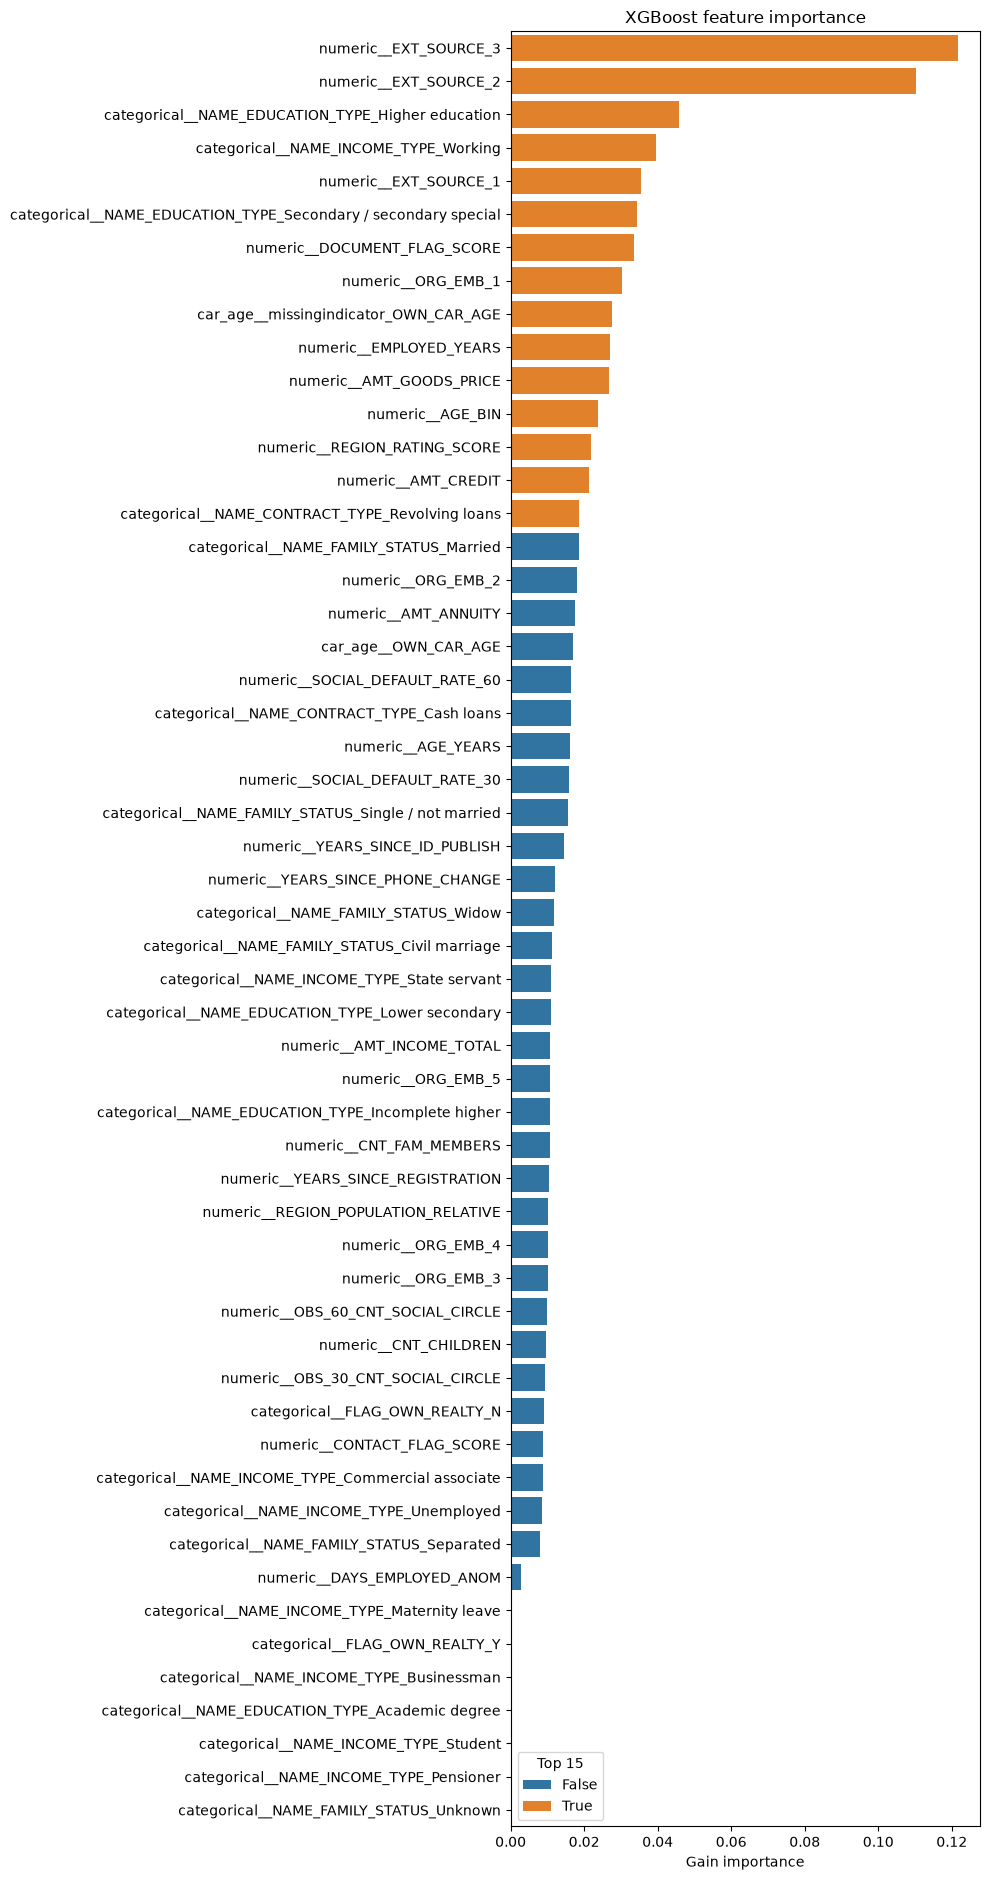

In [153]:
fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(importance_table))))
sns.barplot(
    data=importance_table, x='gain_importance', y='feature',
    hue='top_15', dodge=False, ax=ax,
)
ax.set_title('XGBoost feature importance')
ax.set_xlabel('Gain importance')
ax.set_ylabel('')
ax.legend(title='Top 15')
plt.tight_layout()
plt.show()


### Training curves
Track log loss, F1, and ROC AUC for the combined model on train and validation data. Choose one F1 probability threshold from training predictions, then use it for both F1 curves.


F1 threshold (chosen on train): 0.152


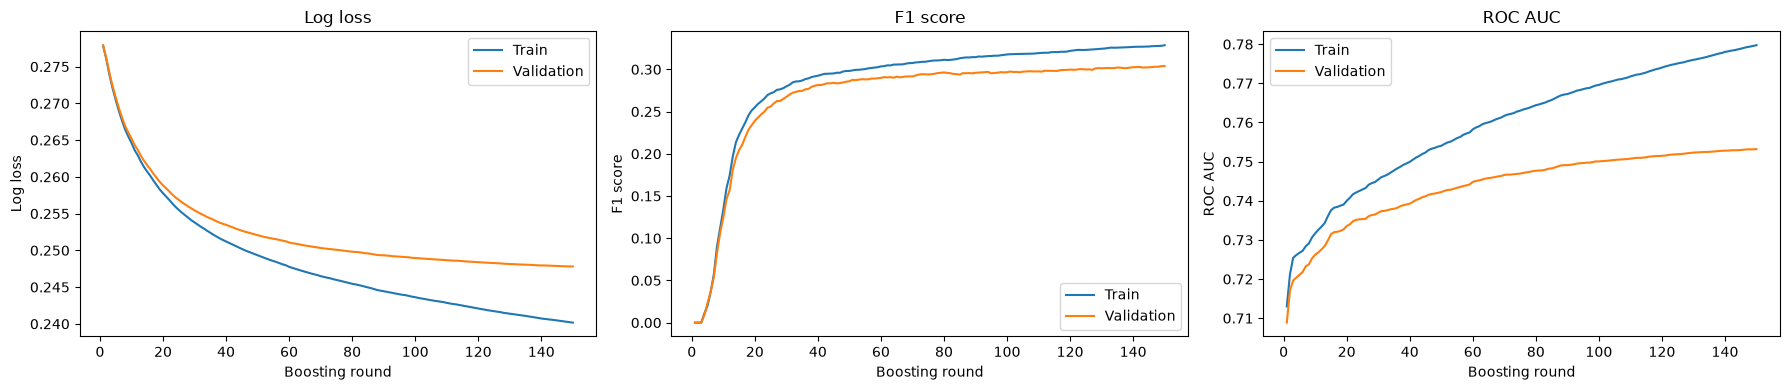

In [154]:
from sklearn.metrics import f1_score, precision_recall_curve
from xgboost import DMatrix, train as train_xgb

train_probabilities = model.predict_proba(X_train)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, train_probabilities)
train_f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
f1_threshold = thresholds[np.argmax(train_f1)]
print(f'F1 threshold (chosen on train): {f1_threshold:.3f}')

train_processed = model[:-1].transform(X_train)
val_processed = model[:-1].transform(X_val)
train_matrix = DMatrix(train_processed, label=y_train)
val_matrix = DMatrix(val_processed, label=y_val)

def f1_metric(y_pred, data):
    return 'f1', f1_score(data.get_label(), y_pred >= f1_threshold, zero_division=0)

params = {key: value for key, value in xgb.get_xgb_params().items() if value is not None}
params['eval_metric'] = ['logloss', 'auc']
history = {}
curve_model = train_xgb(
    params, train_matrix, num_boost_round=xgb.n_estimators,
    evals=[(train_matrix, 'train'), (val_matrix, 'validation')],
    custom_metric=f1_metric, evals_result=history, verbose_eval=False,
)
rounds = range(1, len(history['train']['logloss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, metric, title in zip(axes, ['logloss', 'f1', 'auc'], ['Log loss', 'F1 score', 'ROC AUC']):
    sns.lineplot(x=rounds, y=history['train'][metric], ax=ax, label='Train')
    sns.lineplot(x=rounds, y=history['validation'][metric], ax=ax, label='Validation')
    ax.set_title(title)
    ax.set_xlabel('Boosting round')
    ax.set_ylabel(title)
plt.tight_layout()
plt.show()


### Train and validation scores
Evaluate the combined model before its train-plus-validation refit. The confusion matrix uses an F1 threshold chosen from training predictions only.


     split  ROC AUC
     Train 0.779742
Validation 0.753186

Decision threshold (chosen on train): 0.152
              precision    recall  f1-score   support

           0       0.94      0.89      0.92     56537
           1       0.25      0.40      0.30      4965

    accuracy                           0.85     61502
   macro avg       0.60      0.64      0.61     61502
weighted avg       0.89      0.85      0.87     61502



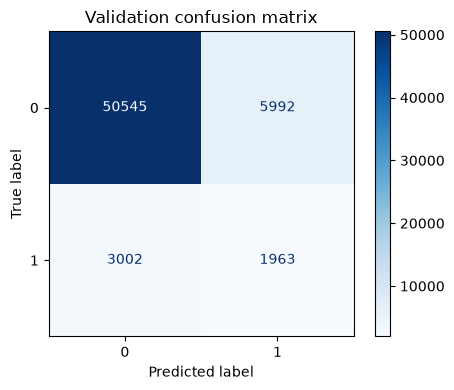

In [155]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_recall_curve, roc_auc_score

train_scores = model.predict_proba(X_train)[:, 1]
val_scores = model.predict_proba(X_val)[:, 1]
roc_auc_table = pd.DataFrame({
    'split': ['Train', 'Validation'],
    'ROC AUC': [roc_auc_score(y_train, train_scores), roc_auc_score(y_val, val_scores)],
})
print(roc_auc_table.to_string(index=False))

precision, recall, thresholds = precision_recall_curve(y_train, train_scores)
train_f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
decision_threshold = thresholds[np.argmax(train_f1)]
val_predictions = (val_scores >= decision_threshold).astype(int)
print(f'\nDecision threshold (chosen on train): {decision_threshold:.3f}')
print(classification_report(y_val, val_predictions, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, val_predictions, display_labels=[0, 1],
    cmap='Blues', values_format='d', ax=ax,
)
ax.set_title('Validation confusion matrix')
plt.tight_layout()
plt.show()


### Final held-out test score
Refit the same pipeline on train plus validation, including its organization embedding, and score the held-out test split once.


In [156]:
final_model = clone(model).fit(X_train_val, y_train_val)
print('Test ROC AUC:', roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1]))


Test ROC AUC: 0.7550382694069495
